*** Exercise ***

import numpy as np 
from sklearn.datasets import make_classification 
from sklearn.model_selection import train_test_split
 from sklearn.linear_model import LogisticRegression 
from sklearn.metrics import precision_recall_curve, auc
 import matplotlib.pyplot as plt
 # Step 1: Generate an imbalanced dataset
 X, y = make_classification(     n_samples=1000,     n_features=20,     n_informative=2,     n_redundant=10,     n_clusters_per_class=1,     weights=[0.9, 0.1],  # 90% of class 0, 10% of class 1     flip_y=0,     random_state=42 )
 
You are provided with a labeled dataset containing features and target variables.. Your task is to develop an AI/ML model, train it using the dataset, and evaluate its performance using appropriate metrics. Create your questions and conclusion.
 

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc, classification_report, confusion_matrix

In [15]:
# Step 1: Generate an imbalanced dataset
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=2,
    n_redundant=10,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],  # 90% class 0, 10% class 1
    flip_y=0,
    random_state=42
)



In [16]:
# Step 2: Split dataset using stratified sampling to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
# Step 3: Train Logistic Regression model
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [18]:
# Step 4: Generate predictions and probabilities
y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

In [23]:
# Step 5: Evaluate Precision-Recall and PR-AUC
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)

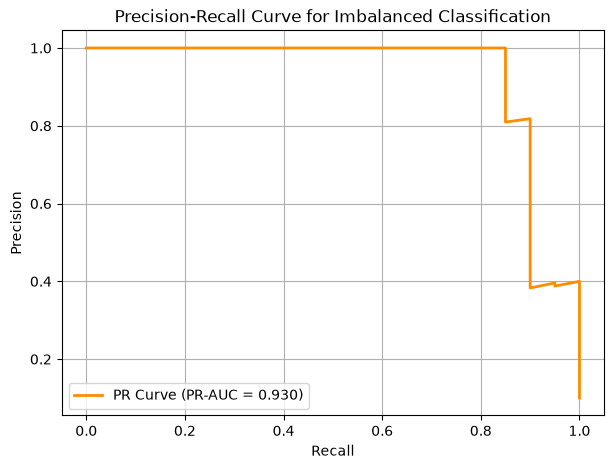

In [24]:
# Step 6: Plot Precision-Recall Curve
plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color="darkorange", lw=2, label=f"PR Curve (PR-AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Imbalanced Classification")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

In [25]:
# Print Evaluation Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Area Under Precision-Recall Curve (PR-AUC):", round(pr_auc, 4))

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       180
           1       0.94      0.85      0.89        20

    accuracy                           0.98       200
   macro avg       0.96      0.92      0.94       200
weighted avg       0.98      0.98      0.98       200

Area Under Precision-Recall Curve (PR-AUC): 0.9299


Question 1: Why is standard Accuracy an unsuitable evaluation metric for this dataset?

Answer: With a $90:10$ class ratio, a dummy classifier predicting the majority class (Class 0) every time would achieve $90\%$ accuracy while failing completely to detect the minority class (Class 1).

Question 2: Why is Precision-Recall AUC preferred over ROC-AUC for imbalanced datasets?

Answer: ROC-AUC includes True Negative Rate (Specificity), which remains artificially high in imbalanced datasets due to the abundance of majority class samples. PR-AUC focuses specifically on the minority class performance (Precision and Recall).

Question 3: How can model performance on the minority class be further improved?

Answer: Techniques such as SMOTE (oversampling minority class), adjusting the decision threshold, setting class_weight='balanced', or using tree-based ensemble algorithms like Random Forest or XGBoost.